In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [30]:
df = pd.read_excel("Cleaned_Sales_Dataset.xlsx")

In [31]:
display(df.head())

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Year,Month,Quarter,Day,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,February,1,Tuesday,Young Adult
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,October,4,Tuesday,Senior
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,May,2,Tuesday,Senior
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,December,4,Tuesday,Senior
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,November,4,Thursday,Adult


In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
 12  Year           1000 non-null   int64         
 13  Month          1000 non-null   object        
 14  Quarter        1000 non-null   int64         
 15  Day            1000 no

In [33]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 17


In [34]:
display(df.describe())

,Order_Date,Age,Quantity,Unit_Price,Total_Sales,Year,Quarter
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.353000,5.435000,25486.783410,139399.439650,2025.005000,2.499000
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000,2025.000000,1.000000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500,2025.000000,1.000000
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000,2025.000000,2.000000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500,2025.000000,4.000000
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000,2026.000000,4.000000
std,NaN,13.683626,2.838632,14179.402361,114100.051546,0.070569,1.131937


In [35]:
display(df.describe(include='object'))

,Order_ID,Customer_ID,Customer_Name,Gender,City,Product,Category,Month,Day,Age_Group
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,992,947,425,2,8,6,5,12,7,5
top,ORD100050,CUST2515,Customer_359,Male,Patna,Mobile,Electronics,December,Sunday,Adult
freq,9,3,8,511,148,184,354,98,153,332


In [36]:
print(df.isnull().sum())

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
Year             0
Month            0
Quarter          0
Day              0
Age_Group        0
dtype: int64


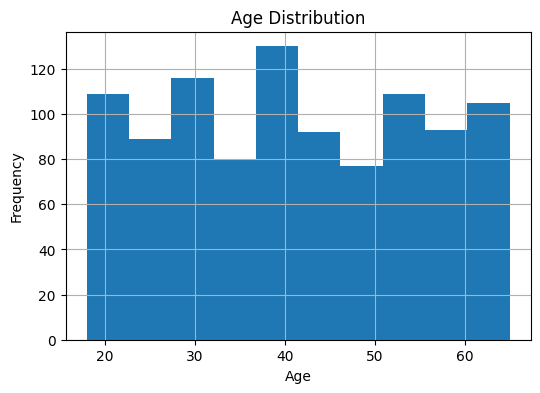

In [37]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

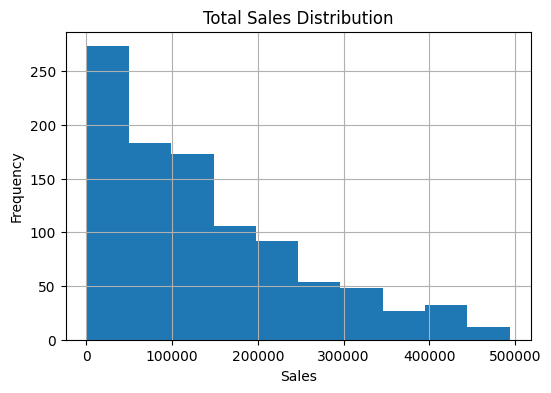

In [38]:
plt.figure(figsize=(6,4))
plt.hist(df["Total_Sales"], bins=10)
plt.title("Total Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

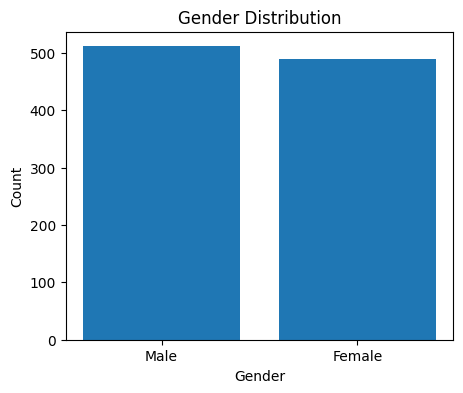

In [39]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(gender.index, gender.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

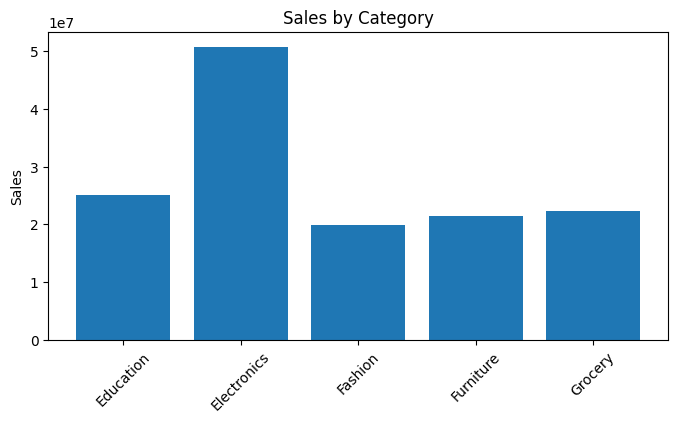

In [40]:
category = df.groupby("Category")["Total_Sales"].sum()

plt.figure(figsize=(8,4))
plt.bar(category.index, category.values)
plt.xticks(rotation=45)
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

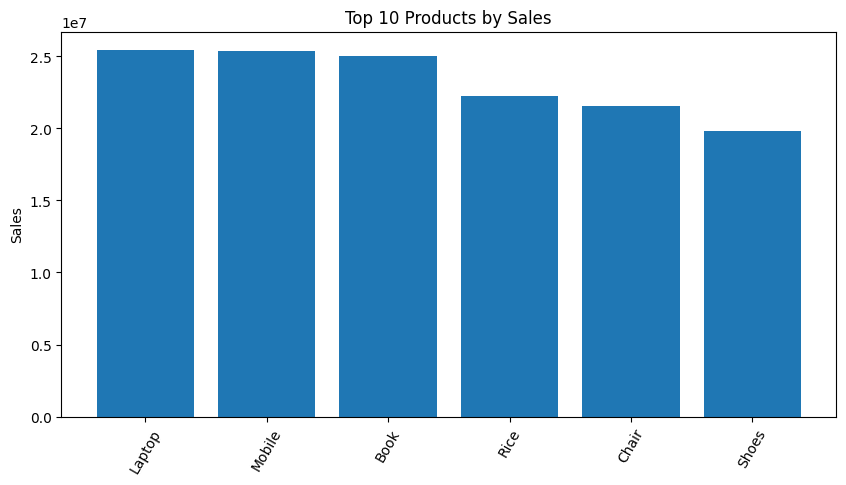

In [41]:
products = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(products.index, products.values)
plt.xticks(rotation=60)
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

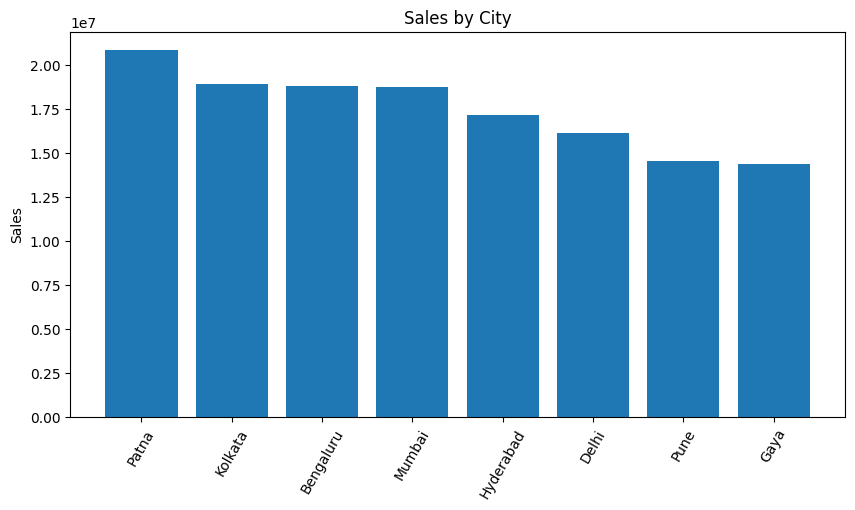

In [42]:
city = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(city.index, city.values)
plt.xticks(rotation=60)
plt.title("Sales by City")
plt.ylabel("Sales")
plt.show()

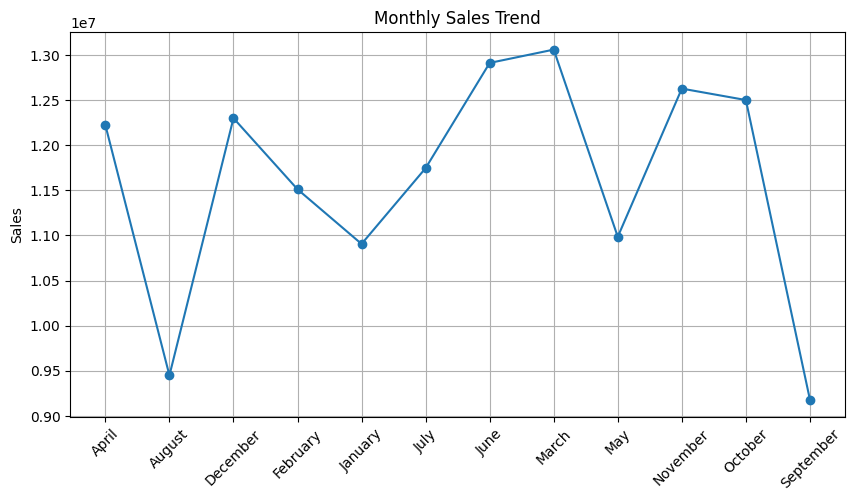

In [43]:
monthly = df.groupby("Month")["Total_Sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

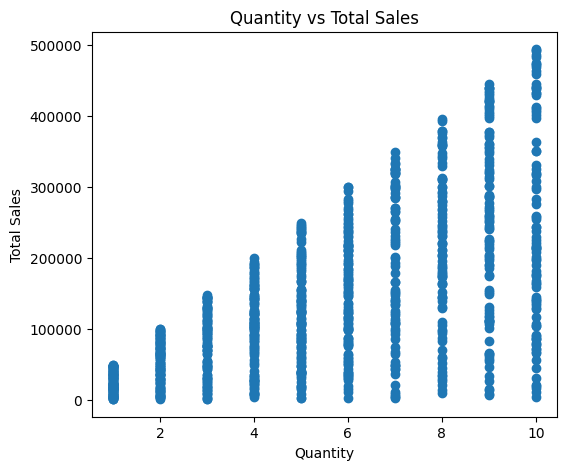

In [44]:
plt.figure(figsize=(6,5))
plt.scatter(df["Quantity"], df["Total_Sales"])
plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.show()

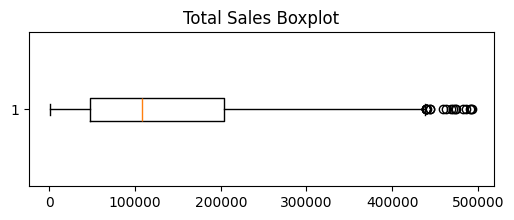

In [45]:
plt.figure(figsize=(6,2))
plt.boxplot(df["Total_Sales"], vert=False)
plt.title("Total Sales Boxplot")
plt.show()

In [46]:
corr = df[["Age","Quantity","Unit_Price","Total_Sales"]].corr()

print(corr)

                  Age  Quantity  Unit_Price  Total_Sales
Age          1.000000 -0.027666   -0.011955     0.001294
Quantity    -0.027666  1.000000    0.021855     0.646641
Unit_Price  -0.011955  0.021855    1.000000     0.686303
Total_Sales  0.001294  0.646641    0.686303     1.000000


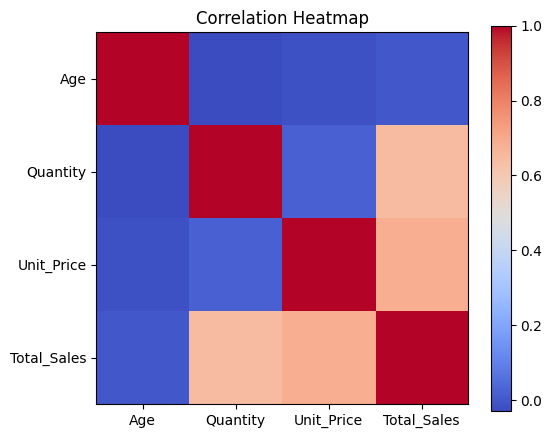

In [47]:
plt.figure(figsize=(6,5))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

In [48]:
conn = sqlite3.connect("sales.db")

df.to_sql("Sales", conn, if_exists="replace", index=False)

1000

In [49]:
query = """
SELECT Product,
SUM(Total_Sales) AS Revenue
FROM Sales
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 5;
"""

display(pd.read_sql(query, conn))

,Product,Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


In [50]:
query = """
SELECT Category,
SUM(Total_Sales) AS Revenue
FROM Sales
GROUP BY Category;
"""

display(pd.read_sql(query, conn))

,Category,Revenue
0,Education,25031689.40
1,Electronics,50778581.70
2,Fashion,19835895.79
3,Furniture,21521561.48
4,Grocery,22231711.28


In [51]:
query = """
SELECT City,
SUM(Total_Sales) AS Sales
FROM Sales
GROUP BY City
ORDER BY Sales DESC;
"""

display(pd.read_sql(query, conn))

,City,Sales
0,Patna,20826584.43
1,Kolkata,18884349.57
2,Bengaluru,18773574.32
3,Mumbai,18757050.17
4,Hyderabad,17166766.87
5,Delhi,16097079.00
6,Pune,14513175.90
7,Gaya,14380859.39


In [52]:
query = """
SELECT AVG(Age) AS Average_Age
FROM Sales;
"""

display(pd.read_sql(query, conn))

,Average_Age
0,41.353


In [53]:
query = """
SELECT Gender,
SUM(Total_Sales) AS Revenue
FROM Sales
GROUP BY Gender;
"""

display(pd.read_sql(query, conn))

,Gender,Revenue
0,Female,66935889.02
1,Male,72463550.63


In [54]:
query = """
SELECT Product,
SUM(Quantity) AS Total_Quantity
FROM Sales
GROUP BY Product
ORDER BY Total_Quantity DESC
LIMIT 1;
"""

display(pd.read_sql(query, conn))

,Product,Total_Quantity
0,Mobile,1008


In [55]:
query = """
SELECT Month,
SUM(Total_Sales) AS Revenue
FROM Sales
GROUP BY Month;
"""

display(pd.read_sql(query, conn))

,Month,Revenue
0,April,12222700.17
1,August,9448471.22
2,December,12299904.44
3,February,11511181.46
4,January,10905580.72
5,July,11746226.80
6,June,12912332.64
7,March,13059899.94
8,May,10984689.25
9,November,12627620.22


In [56]:
print("="*50)

print("Total Revenue :", df["Total_Sales"].sum())

print("Average Revenue :", df["Total_Sales"].mean())

print("Maximum Sale :", df["Total_Sales"].max())

print("Minimum Sale :", df["Total_Sales"].min())

print("Total Orders :", df["Order_ID"].nunique())

print("Unique Customers :", df["Customer_ID"].nunique())

print("="*50)

Total Revenue : 139399439.65
Average Revenue : 139399.43965000001
Maximum Sale : 493677.5
Minimum Sale : 437.34
Total Orders : 992
Unique Customers : 947
